LOading dataset and eda


In [9]:
import pandas as pd

# Loading files with low_memory=False to avoid DtypeWarning
features = pd.read_csv("/content/elliptic_txs_features.csv", low_memory=False)
edges = pd.read_csv("/content/elliptic_txs_edgelist.csv")
classes = pd.read_csv("/content/elliptic_txs_classes.csv")

print("Features shape:", features.shape)
print("Edges shape:", edges.shape)
print("Classes shape:", classes.shape)

print("\n--- Features Preview ---")
display(features.head(2))

print("\n--- Edges Preview ---")
display(edges.head(2))

print("\n--- Classes Preview ---")
display(classes.head(2))

Features shape: (32236, 167)
Edges shape: (234355, 2)
Classes shape: (203769, 2)

--- Features Preview ---


,230425980,1,-0.1714692896288031,-0.18466755143291433,-1.2013688016765636,-0.12196959975910057,-0.04387454791734898,-0.11300200928476244,-0.06158379407303222,-0.16209679981659642,...,-0.5621534802884299,-0.6009988905192808,1.4613303209554889,1.4613689382001922,0.01827940003744589,-0.0874901561101501,-0.13115530389558736,-0.09752359377152515,-0.12061340670311574,-0.11979245961251665
0,5530458,1,-0.171484,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,232022460,1,-0.172107,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792



--- Edges Preview ---


,txId1,txId2
0,230425980,5530458
1,232022460,232438397



--- Classes Preview ---


,txId,class
0,230425980,unknown
1,5530458,unknown


In [10]:
print(features.head())
print(edges.head())
print(classes.head())

   230425980  1  -0.1714692896288031  -0.18466755143291433  \
0    5530458  1            -0.171484             -0.184668   
1  232022460  1            -0.172107             -0.184668   
2  232438397  1             0.163054              1.963790   
3  230460314  1             1.011523             -0.081127   
4  230459870  1             0.961040             -0.081127   

   -1.2013688016765636  -0.12196959975910057  -0.04387454791734898  \
0            -1.201369             -0.121970             -0.043875   
1            -1.201369             -0.121970             -0.043875   
2            -0.646376             12.409294             -0.063725   
3            -1.201369              1.153668              0.333276   
4            -1.201369              1.303743              0.333276   

   -0.11300200928476244  -0.06158379407303222  -0.16209679981659642  ...  \
0             -0.113002             -0.061584             -0.162112  ...   
1             -0.113002             -0.061584         

In [11]:
print(features.columns)
print(edges.columns)
print(classes.columns)

Index(['230425980', '1', '-0.1714692896288031', '-0.18466755143291433',
       '-1.2013688016765636', '-0.12196959975910057', '-0.04387454791734898',
       '-0.11300200928476244', '-0.06158379407303222', '-0.16209679981659642',
       ...
       '-0.5621534802884299', '-0.6009988905192808', '1.4613303209554889',
       '1.4613689382001922', '0.01827940003744589', '-0.0874901561101501',
       '-0.13115530389558736', '-0.09752359377152515', '-0.12061340670311574',
       '-0.11979245961251665'],
      dtype='object', length=167)
Index(['txId1', 'txId2'], dtype='object')
Index(['txId', 'class'], dtype='object')


In [12]:
print(classes.iloc[:, 1].value_counts())

class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64


In [13]:
print(edges.head(10))

       txId1      txId2
0  230425980    5530458
1  232022460  232438397
2  230460314  230459870
3  230333930  230595899
4  232013274  232029206
5  232344069   27553029
6   36411953  230405052
7   34194980    5529846
8    3881097  232457116
9  230409257   32877982


In [14]:
import networkx as nx

G = nx.from_pandas_edgelist(
    edges,
    source=edges.columns[0],
    target=edges.columns[1]
)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
 #network x ka use graph ki analysis karne ke liye use kiya jaa rha hai

Nodes: 203769
Edges: 234355


In [15]:
print("Average degree:", sum(dict(G.degree()).values()) / G.number_of_nodes())

Average degree: 2.3002026804862368


dataset clean and merge

In [16]:
classes.head()

,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown


In [19]:
classes.iloc[:, 1].value_counts().astype(str)

,count
class,
unknown,157205
2,42019
1,4545


In [21]:
known_classes = classes[classes.iloc[:, 1] != "unknown"].copy()

print(known_classes.shape)
print(known_classes.iloc[:, 1].value_counts())

(46564, 2)
class
2    42019
1     4545
Name: count, dtype: int64


In [22]:
features.head()

,230425980,1,-0.1714692896288031,-0.18466755143291433,-1.2013688016765636,-0.12196959975910057,-0.04387454791734898,-0.11300200928476244,-0.06158379407303222,-0.16209679981659642,...,-0.5621534802884299,-0.6009988905192808,1.4613303209554889,1.4613689382001922,0.01827940003744589,-0.0874901561101501,-0.13115530389558736,-0.09752359377152515,-0.12061340670311574,-0.11979245961251665
0,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
2,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
3,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117
4,230459870,1,0.961040,-0.081127,-1.201369,1.303743,0.333276,1.480381,-0.061584,-0.163577,...,-0.504702,-0.422589,-0.226790,-0.117629,0.018279,0.277775,0.413931,1.149556,-0.696053,-0.695540


In [23]:
features.columns[0]

'230425980'

In [24]:
classes.columns

Index(['txId', 'class'], dtype='object')

In [28]:

features_renamed = features.rename(columns={features.columns[0]: 'txId'})

# Merging features and classes using the correct 'txId' column
data = features_renamed.merge(
    known_classes,
    on='txId',
    how="inner"
)

print("Merged Data Shape:", data.shape)
display(data.head())

Merged Data Shape: (7957, 168)


,txId,1,-0.1714692896288031,-0.18466755143291433,-1.2013688016765636,-0.12196959975910057,-0.04387454791734898,-0.11300200928476244,-0.06158379407303222,-0.16209679981659642,...,-0.6009988905192808,1.4613303209554889,1.4613689382001922,0.01827940003744589,-0.0874901561101501,-0.13115530389558736,-0.09752359377152515,-0.12061340670311574,-0.11979245961251665,class
0,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,2
1,232029206,1,-0.005027,0.578941,-0.091383,4.380281,-0.063725,4.667146,0.851305,-0.163645,...,-0.613614,0.241128,0.241406,0.604120,0.008632,-0.131155,0.333211,-0.120613,-0.119792,2
2,232344069,1,-0.147852,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.137933,...,-0.613614,0.241128,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,2
3,27553029,1,-0.151357,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.141519,...,-0.582077,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,2
4,3881097,1,-0.172306,-0.184668,-1.201369,0.028105,-0.043875,-0.029140,0.242712,-0.163640,...,-0.600999,0.241128,0.241406,0.018279,-0.068266,-0.084674,-0.054450,-1.760926,-1.760984,2


In [29]:
label_col = classes.columns[1]

data["label"] = data[label_col].map({
    "1": 1,
    "2": 0
})

In [30]:
print(data["label"].value_counts())

label
0    7872
1      85
Name: count, dtype: int64


In [31]:
data["label"] = data[label_col].astype(str).map({
    "1": 1,
    "2": 0
})

In [32]:
print(data["label"].value_counts())

label
0    7872
1      85
Name: count, dtype: int64


feature engineering- removing transcation id and labels


In [33]:
feature_cols = features.columns[1:]

X = data[feature_cols]
y = data["label"]

In [34]:
print("X:", X.shape)
print("y:", y.shape)

X: (7957, 166)
y: (7957,)


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [38]:
# Using 'txId' instead of features.columns[0] since we renamed it during the merge
node_mapping = {
    tx_id: idx
    for idx, tx_id in enumerate(data['txId'])
}

In [39]:
source_col = edges.columns[0]
target_col = edges.columns[1]

edge_list = []

for _, row in edges.iterrows():

    src = row[source_col]
    dst = row[target_col]

    if src in node_mapping and dst in node_mapping:
        edge_list.append([
            node_mapping[src],
            node_mapping[dst]
        ])

In [40]:
import torch

edge_index = torch.tensor(
    edge_list,
    dtype=torch.long
).t().contiguous()

In [41]:
print(edge_index.shape)

torch.Size([2, 6198])


In [43]:
# Installing PyTorch Geometric since it is not pre-installed in Colab
!pip install -q torch-geometric

from torch_geometric.data import Data

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.0 MB/s eta 0:00:00


In [44]:
x = torch.tensor(
    X_scaled,
    dtype=torch.float
)

In [46]:
y_tensor = torch.tensor(
    y.values,
    dtype=torch.long
)

In [47]:
graph_data = Data(
    x=x,
    edge_index=edge_index,
    y=y_tensor
)

In [48]:
print(graph_data)

Data(x=[7957, 166], edge_index=[2, 6198], y=[7957])


tarining gcn


In [49]:
from sklearn.model_selection import train_test_split
import torch

indices = torch.arange(graph_data.num_nodes)

train_idx, test_idx = train_test_split(
    indices.numpy(),
    test_size=0.2,
    random_state=42,
    stratify=graph_data.y.numpy()
)

train_mask = torch.zeros(graph_data.num_nodes, dtype=torch.bool)
test_mask = torch.zeros(graph_data.num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
test_mask[test_idx] = True

graph_data.train_mask = train_mask
graph_data.test_mask = test_mask

print("Train:", train_mask.sum().item())
print("Test:", test_mask.sum().item())

Train: 6365
Test: 1592


In [50]:
from torch_geometric.nn import GCNConv

In [51]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv


class GCN(torch.nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()

        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)

        return x

In [52]:
input_dim = graph_data.num_node_features

print(input_dim)

166


In [53]:
model = GCN(
    input_dim=input_dim,
    hidden_dim=64,
    output_dim=2
)

print(model)

GCN(
  (conv1): GCNConv(166, 64)
  (conv2): GCNConv(64, 2)
)


In [54]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=5e-4
)

In [55]:
criterion = torch.nn.CrossEntropyLoss()

In [56]:
def train():

    model.train()

    optimizer.zero_grad()

    out = model(
        graph_data.x,
        graph_data.edge_index
    )

    loss = criterion(
        out[graph_data.train_mask],
        graph_data.y[graph_data.train_mask]
    )

    loss.backward()

    optimizer.step()

    return loss.item()

In [57]:
for epoch in range(1, 101):

    loss = train()

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | Loss: {loss:.4f}"
        )

Epoch 010 | Loss: 0.0505
Epoch 020 | Loss: 0.0353
Epoch 030 | Loss: 0.0228
Epoch 040 | Loss: 0.0174
Epoch 050 | Loss: 0.0140
Epoch 060 | Loss: 0.0119
Epoch 070 | Loss: 0.0104
Epoch 080 | Loss: 0.0094
Epoch 090 | Loss: 0.0086
Epoch 100 | Loss: 0.0081


In [58]:
from sklearn.metrics import classification_report

model.eval()

with torch.no_grad():

    out = model(
        graph_data.x,
        graph_data.edge_index
    )

    predictions = out.argmax(dim=1)

print(
    classification_report(
        graph_data.y[graph_data.test_mask].numpy(),
        predictions[graph_data.test_mask].numpy(),
        target_names=["Licit", "Illicit"]
    )
)

              precision    recall  f1-score   support

       Licit       0.99      1.00      1.00      1575
     Illicit       0.70      0.41      0.52        17

    accuracy                           0.99      1592
   macro avg       0.85      0.70      0.76      1592
weighted avg       0.99      0.99      0.99      1592



In [59]:
import torch

train_labels = graph_data.y[graph_data.train_mask]

class_counts = torch.bincount(train_labels)

print("Licit:", class_counts[0].item())
print("Illicit:", class_counts[1].item())

Licit: 6297
Illicit: 68


In [60]:
class_counts = torch.bincount(train_labels)

weights = class_counts.sum() / (
    len(class_counts) * class_counts.float()
)

print(weights)

tensor([ 0.5054, 46.8015])


In [61]:
criterion = torch.nn.CrossEntropyLoss(
    weight=weights
)

In [62]:
model = GCN(
    input_dim=graph_data.num_node_features,
    hidden_dim=64,
    output_dim=2
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=5e-4
)

In [63]:
for epoch in range(1, 101):

    model.train()

    optimizer.zero_grad()

    out = model(
        graph_data.x,
        graph_data.edge_index
    )

    loss = criterion(
        out[graph_data.train_mask],
        graph_data.y[graph_data.train_mask]
    )

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | Loss: {loss.item():.4f}"
        )

Epoch 010 | Loss: 0.1058
Epoch 020 | Loss: 0.0420
Epoch 030 | Loss: 0.0227
Epoch 040 | Loss: 0.0154
Epoch 050 | Loss: 0.0116
Epoch 060 | Loss: 0.0095
Epoch 070 | Loss: 0.0082
Epoch 080 | Loss: 0.0073
Epoch 090 | Loss: 0.0067
Epoch 100 | Loss: 0.0063


In [64]:
model.eval()

with torch.no_grad():

    out = model(
        graph_data.x,
        graph_data.edge_index
    )

    predictions = out.argmax(dim=1)

In [65]:
test_y = graph_data.y[graph_data.test_mask]
test_pred = predictions[graph_data.test_mask]

In [66]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_y.numpy(),
        test_pred.numpy(),
        target_names=["Licit", "Illicit"]
    )
)

              precision    recall  f1-score   support

       Licit       1.00      1.00      1.00      1575
     Illicit       0.59      0.59      0.59        17

    accuracy                           0.99      1592
   macro avg       0.79      0.79      0.79      1592
weighted avg       0.99      0.99      0.99      1592



In [67]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    test_y.numpy(),
    test_pred.numpy()
)

print(cm)

[[1568    7]
 [   7   10]]


In [68]:
probabilities = torch.softmax(out, dim=1)

illicit_probability = probabilities[:, 1]

In [69]:
model.eval()

with torch.no_grad():
    out = model(
        graph_data.x,
        graph_data.edge_index
    )

    probabilities = torch.softmax(out, dim=1)

test_mask = graph_data.test_mask

test_y = graph_data.y[test_mask].cpu().numpy()

test_pred = out[test_mask].argmax(dim=1).cpu().numpy()

test_prob = probabilities[test_mask][:, 1].cpu().numpy()

In [70]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_y,
        test_pred,
        target_names=["Licit", "Illicit"],
        digits=4
    )
)

              precision    recall  f1-score   support

       Licit     0.9956    0.9956    0.9956      1575
     Illicit     0.5882    0.5882    0.5882        17

    accuracy                         0.9912      1592
   macro avg     0.7919    0.7919    0.7919      1592
weighted avg     0.9912    0.9912    0.9912      1592



In [71]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_y, test_pred)

print(cm)

[[1568    7]
 [   7   10]]


In [72]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    test_y,
    test_prob
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9641083099906628


In [73]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(
    test_y,
    test_prob
)

print("PR-AUC:", pr_auc)

PR-AUC: 0.45141946089064405


In [74]:
import networkx as nx

G = nx.from_pandas_edgelist(
    edges,
    source=edges.columns[0],
    target=edges.columns[1]
)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 203769
Edges: 234355


In [77]:
transaction_ids = data['txId'].values

prediction_df = pd.DataFrame({
    "txId": transaction_ids,
    "actual": y.values,
    "prediction": predictions.cpu().numpy(),
    "illicit_probability": illicit_probability.cpu().numpy()
})

prediction_df.head()

,txId,actual,prediction,illicit_probability
0,232438397,0,0,2.101948e-44
1,232029206,0,0,5.598852e-21
2,232344069,0,0,4.462876e-06
3,27553029,0,0,2.589684e-08
4,3881097,0,0,0.000000e+00


In [78]:
tx_id = transaction_ids[0]

print("Transaction:", tx_id)

Transaction: 232438397


In [79]:
neighbors = list(G.neighbors(tx_id))

print("Number of neighbors:", len(neighbors))
print("Neighbors:", neighbors[:20])

Number of neighbors: 161
Neighbors: [232022460, 232047899, 3877118, 92491280, 230452718, 230456717, 230556037, 230456719, 232023529, 230402893, 230412047, 208537161, 230417569, 3878718, 230425284, 230438854, 232007342, 230423848, 230472241, 232043907]


In [80]:
neighbor_info = prediction_df[
    prediction_df["txId"].isin(neighbors)
]

neighbor_info.sort_values(
    "illicit_probability",
    ascending=False
).head(10)

,txId,actual,prediction,illicit_probability
939,16754007,1,0,0.022217
33,230423018,0,0,0.006749
1432,3875136,0,0,0.001637
69,230449518,0,0,0.001006
852,3878606,0,0,0.000830
1191,230456734,0,0,0.000361
506,232061267,0,0,0.000343
1136,230647320,0,0,0.000279
900,71367715,0,0,0.000271
2055,230390558,0,0,0.000249


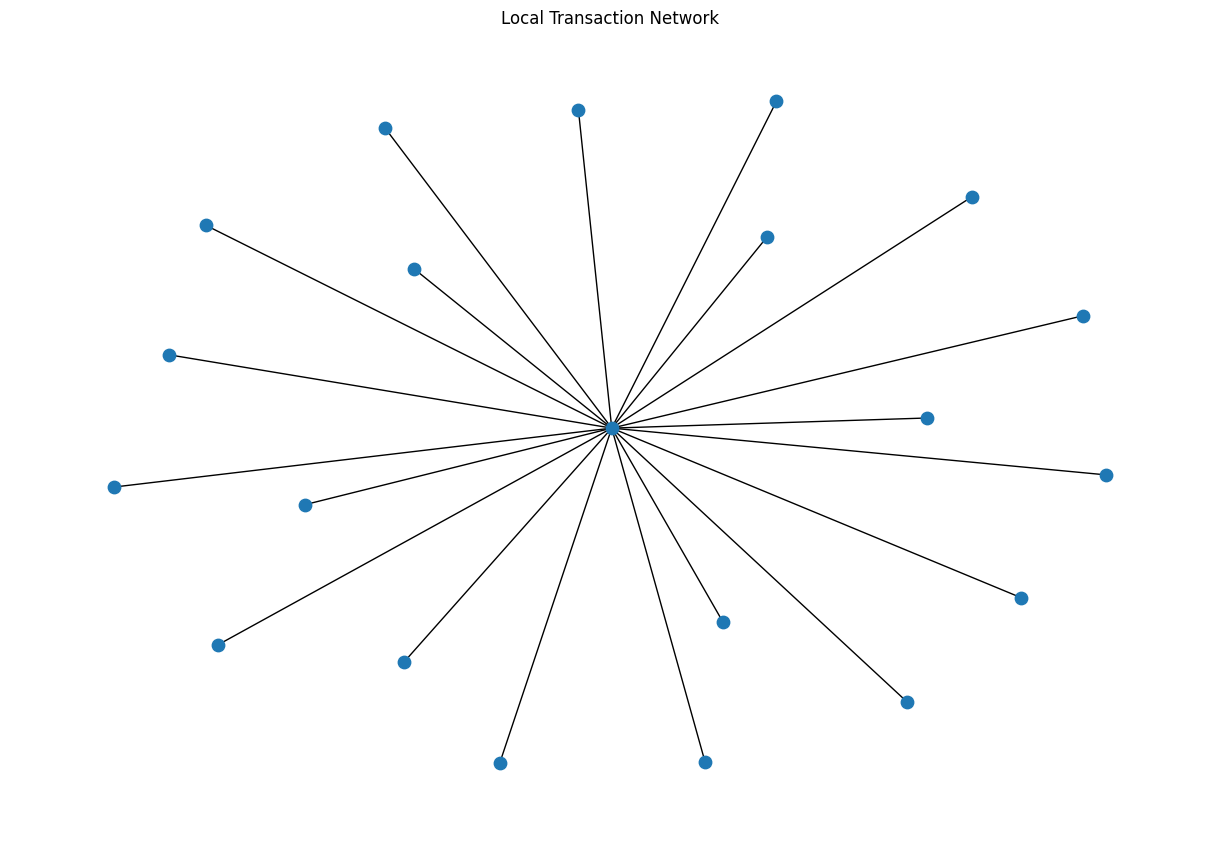

In [81]:
import matplotlib.pyplot as plt

sub_nodes = [tx_id] + neighbors[:20]

subgraph = G.subgraph(sub_nodes)

plt.figure(figsize=(12, 8))

nx.draw(
    subgraph,
    with_labels=False,
    node_size=80
)

plt.title("Local Transaction Network")

plt.show()

In [82]:
node_colors = []

for node in subgraph.nodes():

    if node == tx_id:
        node_colors.append("yellow")

    else:

        row = prediction_df[
            prediction_df["txId"] == node
        ]

        if len(row) == 0:
            node_colors.append("gray")

        elif row["prediction"].iloc[0] == 1:
            node_colors.append("red")

        else:
            node_colors.append("green")

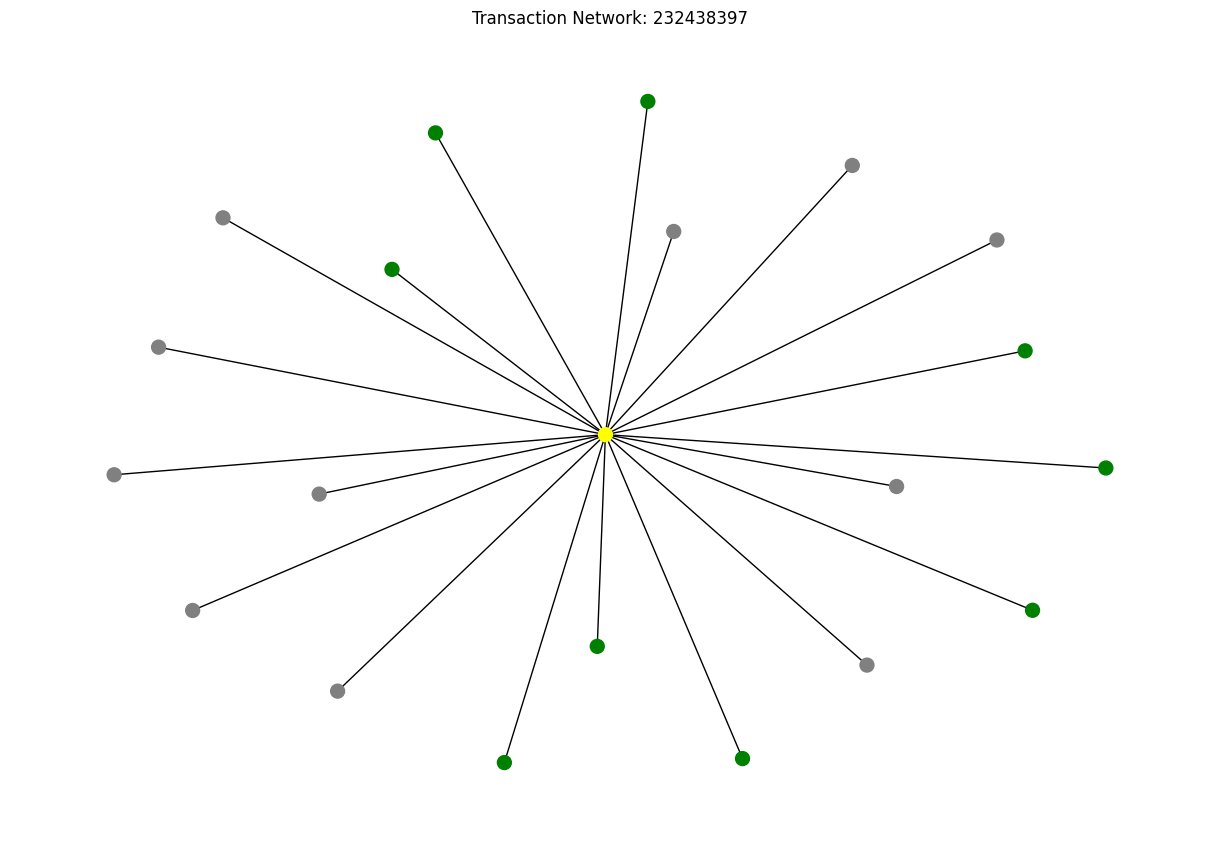

In [83]:
plt.figure(figsize=(12, 8))

nx.draw(
    subgraph,
    with_labels=False,
    node_color=node_colors,
    node_size=100
)

plt.title(
    f"Transaction Network: {tx_id}"
)

plt.show()

In [84]:
torch.save(model.state_dict(), "gcn_model.pth")